# 02 — Exploratory Data Analysis

Five sections: England's long-run completions history (1946–2025), the recent national net additions trend, local authority variation and Huntingdonshire's position, the affordable housing tenure shift, and the starts-vs-completions pipeline. The aim is to understand what the data shows before deciding how to structure the dashboard.

In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import Image as IPImage, display
from pathlib import Path

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

HDC_CODE = 'E07000011'
HDC_NAME = 'Huntingdonshire'

In [2]:
england   = pd.read_csv(PROCESSED / 'completions_england.csv')
net_la    = pd.read_csv(PROCESSED / 'net_additions_la.csv')
net_reg   = pd.read_csv(PROCESSED / 'net_additions_regional.csv')
affordable = pd.read_csv(PROCESSED / 'affordable_completions_la.csv')
starts_la  = pd.read_csv(PROCESSED / 'starts_completions_la.csv')

print('completions_england:   ', england.shape)
print('net_additions_la:      ', net_la.shape)
print('net_additions_regional:', net_reg.shape)
print('affordable_completions:', affordable.shape)
print('starts_completions_la: ', starts_la.shape)

completions_england:    (80, 9)
net_additions_la:       (10104, 4)
net_additions_regional: (3170, 4)
affordable_completions: (36444, 7)
starts_completions_la:  (14553, 11)


## England housing completions by sector, 1946–2025

The `completions_england` table splits delivery into three sectors: private developers, housing associations, and local authorities. Three sectors, eight decades, and one structural story about why England has a housing shortage.

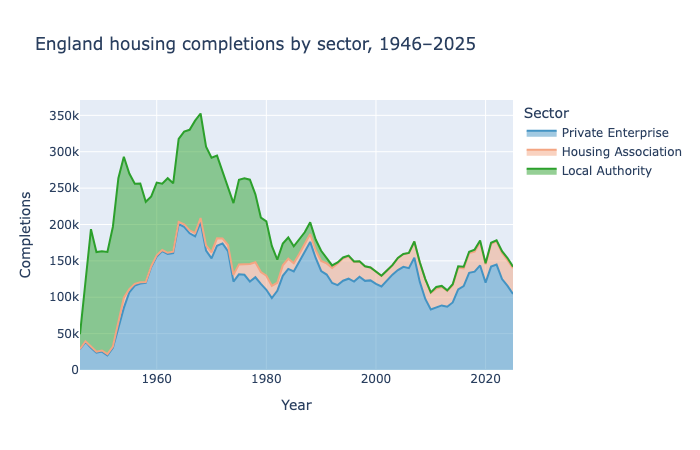

In [3]:
comp_cols = [
    'Private Enterprise Completions',
    'Housing Association Completions',
    'Local Authority Completions',
]
comp = england[['year'] + comp_cols].copy()
comp_long = comp.melt(id_vars='year', value_vars=comp_cols,
                      var_name='sector', value_name='completions')
comp_long['sector'] = comp_long['sector'].str.replace(' Completions', '', regex=False)

fig = px.area(
    comp_long,
    x='year', y='completions', color='sector',
    title='England housing completions by sector, 1946\u20132025',
    labels={'completions': 'Completions', 'year': 'Year', 'sector': 'Sector'},
    color_discrete_map={
        'Private Enterprise': '#4393c3',
        'Housing Association': '#f4a582',
        'Local Authority':    '#2ca02c',
    },
)
fig.update_layout(height=450, hovermode='x unified')
fig.write_image(str(FIGURES / '01_england_completions_history.png'))
display(IPImage(str(FIGURES / '01_england_completions_history.png')))

The peak was around 425,000 completions in 1968, driven mainly by local authority building. The Housing Act 1980 introduced Right to Buy, letting council tenants purchase their homes at a discount and restricting councils from reinvesting the proceeds. LA completions collapsed from the early 1980s and have never recovered. Housing associations grew from the 1990s onwards but not at anything close to the scale needed to replace LA output. Private completions have been the dominant and volatile component since the mid-1980s, tracking economic cycles. The post-2008 crash dip is visible, as is the fall from 2022 onwards following the rise in interest rates that increased the cost of development finance.

## England net additional dwellings, 2001-02 to 2024-25

Net additional dwellings is the headline delivery metric in modern housing policy. It accounts for new build completions plus conversions and change of use, minus demolitions. The government has had a stated target of 300,000 homes per year since around 2015. England has never hit it.

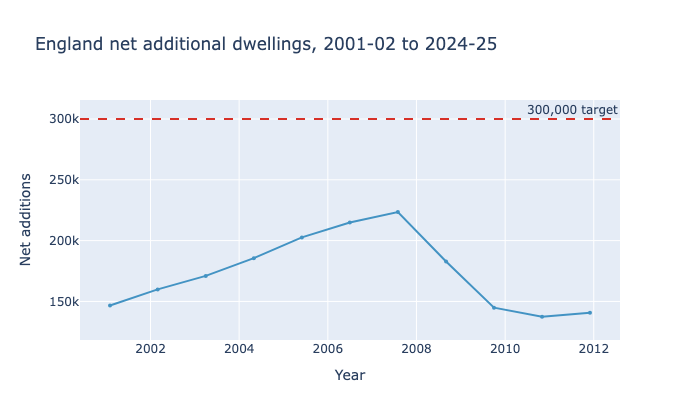

In [4]:
net_eng = net_la[net_la['ons_code'] == 'E92000001'].sort_values('year').copy()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=net_eng['year'], y=net_eng['net_additions'],
    name='Net additions', mode='lines+markers',
    line=dict(color='#4393c3', width=2),
    marker=dict(size=4),
))
fig.add_hline(
    y=300_000, line_dash='dash', line_color='#d73027',
    annotation_text='300,000 target',
    annotation_position='top right',
)
fig.update_layout(
    title='England net additional dwellings, 2001-02 to 2024-25',
    xaxis_title='Year', yaxis_title='Net additions',
    height=420, hovermode='x unified',
)
fig.write_image(str(FIGURES / '02_england_net_additions.png'))
display(IPImage(str(FIGURES / '02_england_net_additions.png')))

The closest approach was 248,591 in 2019-20. England has never reached 300,000. The 2020-21 pandemic year fell to 217,754. The partial recovery peaked at 234,292 in 2022-23, and delivery has been falling since: 221,409 in 2023-24 and 208,600 in 2024-25 (provisional). That 2024-25 figure is 30% below the government target.

## Local authority variation in 2024-25

I'm filtering to shire districts (ONS code prefix E07) to compare Huntingdonshire against authorities of the same type. Metropolitan districts, London boroughs, and unitary authorities operate in different planning and land-supply contexts and are not meaningful comparators for a rural-suburban Cambridgeshire district.

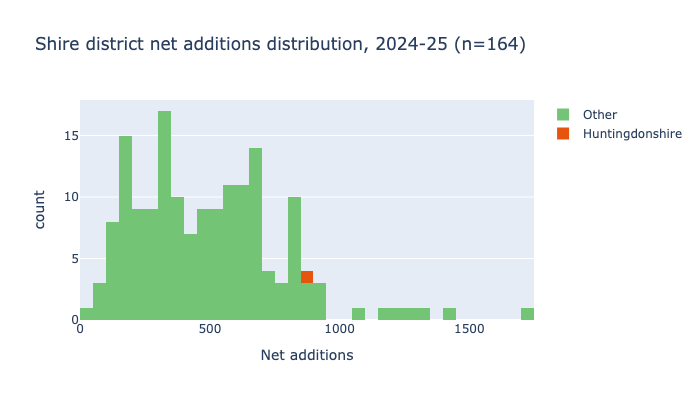

Huntingdonshire 2024-25: 858 net additions
Rank: 14 of 164 shire districts (1 = highest delivery)
Percentile: top 9%


In [5]:
la_2024 = net_la[
    (net_la['year'] == '2024-25') &
    (net_la['ons_code'].str.startswith('E07', na=False))
].copy()
la_2024 = la_2024.dropna(subset=['net_additions'])
la_2024 = la_2024.sort_values('net_additions', ascending=False).reset_index(drop=True)
la_2024['rank'] = la_2024.index + 1
la_2024['highlight'] = la_2024['ons_code'].apply(
    lambda x: HDC_NAME if x == HDC_CODE else 'Other'
)

hdc_row = la_2024[la_2024['ons_code'] == HDC_CODE].iloc[0]
hdc_rank = int(hdc_row['rank'])
n_total  = len(la_2024)
hdc_val  = int(hdc_row['net_additions'])

fig = px.histogram(
    la_2024, x='net_additions',
    color='highlight',
    color_discrete_map={HDC_NAME: '#e6550d', 'Other': '#74c476'},
    nbins=40,
    title=f'Shire district net additions distribution, 2024-25 (n={n_total})',
    labels={'net_additions': 'Net additions', 'count': 'Districts', 'highlight': ''},
)
fig.update_layout(height=400, hovermode='x unified')
fig.write_image(str(FIGURES / '03_la_distribution_2024.png'))
display(IPImage(str(FIGURES / '03_la_distribution_2024.png')))

print(f'Huntingdonshire 2024-25: {hdc_val:,} net additions')
print(f'Rank: {hdc_rank} of {n_total} shire districts (1 = highest delivery)')
percentile = round(100 * (1 - hdc_rank / n_total))
print(f'Percentile: top {100 - percentile}%')

Huntingdonshire ranks 14th of 164 shire districts in 2024-25, placing it in the top 9% by delivery volume. The distribution is right-skewed: most shire districts deliver fewer than 500 homes per year, with a long tail of high-delivery districts concentrated in growth areas like the Oxford-Cambridge arc and the South East. Even at 858, a 31% fall from the 2022-23 peak of 1,250, Huntingdonshire is still delivering well above the median shire district.

## East of England in regional context

Huntingdonshire is in the East of England, historically one of the higher-growth regions in England outside London. The net_additions_regional table has regional totals from 2000-01 to 2024-25.

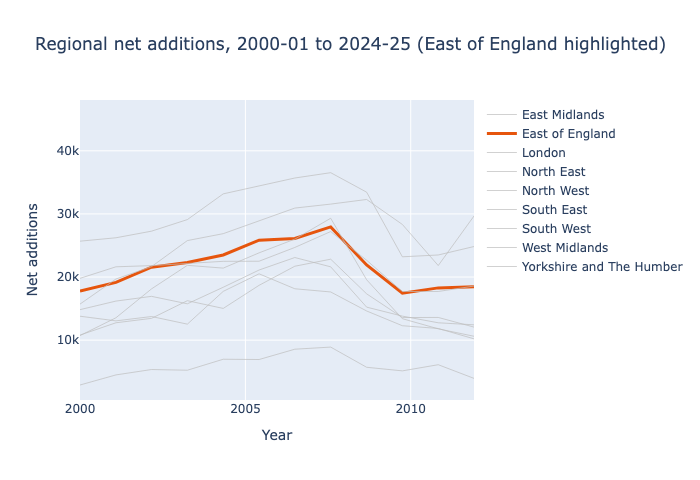

East of England recent trend:
   year   value
2020-21 25661.0
2021-22 27457.0
2022-23 30771.0
2023-24 28643.0
2024-25 26012.0


In [6]:
net_additions = net_reg[
    (net_reg['component'] == 'Net additions') &
    (net_reg['region'] != 'England')
].copy()

fig = go.Figure()
for region in sorted(net_additions['region'].unique()):
    df_r = net_additions[net_additions['region'] == region].sort_values('year')
    is_eoe = region == 'East of England'
    fig.add_trace(go.Scatter(
        x=df_r['year'], y=df_r['value'],
        name=region, mode='lines',
        line=dict(
            width=3 if is_eoe else 1,
            color='#e6550d' if is_eoe else '#bdbdbd',
        ),
        opacity=1.0 if is_eoe else 0.7,
    ))

fig.update_layout(
    title='Regional net additions, 2000-01 to 2024-25 (East of England highlighted)',
    xaxis_title='Year', yaxis_title='Net additions',
    height=480, hovermode='x unified',
)
fig.write_image(str(FIGURES / '04_regional_net_additions.png'))
display(IPImage(str(FIGURES / '04_regional_net_additions.png')))

eoe = net_additions[net_additions['region'] == 'East of England'].sort_values('year')
print('East of England recent trend:')
print(eoe.tail(5)[['year','value']].to_string(index=False))

The East of England peaked at 30,771 net additions in 2022-23 and fell to 26,012 in 2024-25, a 15% drop in two years. The regional trend mirrors the national picture: a post-pandemic partial recovery cut short by rising interest rates. The East of England typically sits in the top two or three regions by volume, behind London and the South East, reflecting sustained population and economic growth pressure.

## Affordable housing: the tenure shift, 1991-92 to 2024-25

Affordable housing tenure is where housing policy change is most visible in the data. In 2011 the coalition government replaced capital grant funding for social rent (typically 40-60% of market rent) with a new affordable rent product at up to 80% of market rent. That change drove a rapid shift in what actually gets built under the affordable label.

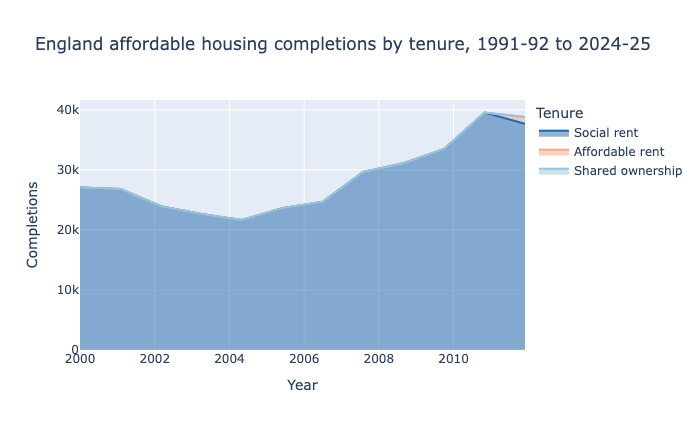

In [7]:
aff_eng = (
    affordable[affordable['tenure'] != 'total_affordable']
    .groupby(['year', 'tenure'])['completions']
    .sum()
    .reset_index()
)

tenure_labels = {
    'social_rent':    'Social rent',
    'affordable_rent': 'Affordable rent',
    'shared_ownership': 'Shared ownership',
}
aff_eng['tenure_label'] = aff_eng['tenure'].map(tenure_labels)
tenure_order = ['Social rent', 'Affordable rent', 'Shared ownership']

fig = px.area(
    aff_eng.sort_values(['year', 'tenure_label']),
    x='year', y='completions', color='tenure_label',
    category_orders={'tenure_label': tenure_order},
    title='England affordable housing completions by tenure, 1991-92 to 2024-25',
    labels={'completions': 'Completions', 'year': 'Year', 'tenure_label': 'Tenure'},
    color_discrete_map={
        'Social rent':      '#2166ac',
        'Affordable rent':  '#f4a582',
        'Shared ownership': '#92c5de',
    },
)
fig.update_layout(height=430, hovermode='x unified')
fig.write_image(str(FIGURES / '05_affordable_tenure_shift.png'))
display(IPImage(str(FIGURES / '05_affordable_tenure_shift.png')))

Social rent completions peaked in the mid-2000s and then fell sharply after 2010. Affordable rent rose from near zero in 2011 to become the dominant affordable tenure by 2015. Shared ownership has remained a smaller but consistent component. The total affordable figure can look reasonable in recent years, but a growing share is affordable rent rather than social rent. In a high house price area like Huntingdonshire, 80% of market rent is not affordable for most households in housing need, so the tenure composition matters as much as the headline total.

## Huntingdonshire affordable delivery

Huntingdonshire's affordable breakdown shows the same tenure shift visible nationally, alongside a sharp drop in total affordable completions in 2024-25.

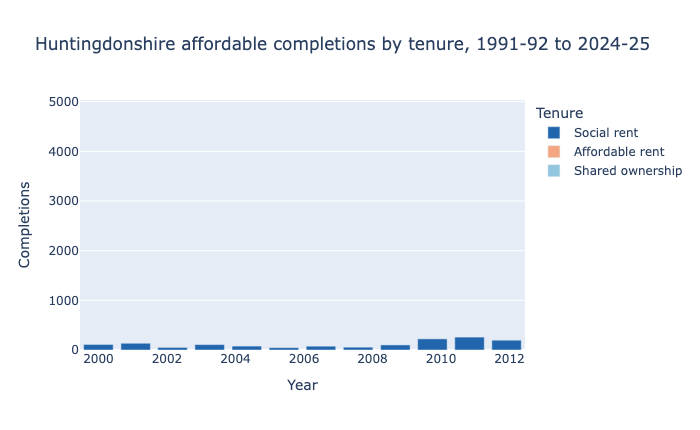

Huntingdonshire affordable delivery rate (% of net additions):
year
2019-20    53.4
2020-21    34.9
2021-22    36.4
2022-23    36.7
2023-24    47.6
2024-25    38.2


In [8]:
hdc_aff = affordable[
    (affordable['ons_code'] == HDC_CODE) &
    (affordable['tenure'] != 'total_affordable')
].copy()
hdc_aff['tenure_label'] = hdc_aff['tenure'].map(tenure_labels)

fig = px.bar(
    hdc_aff.sort_values('year'),
    x='year', y='completions', color='tenure_label',
    category_orders={'tenure_label': tenure_order},
    title='Huntingdonshire affordable completions by tenure, 1991-92 to 2024-25',
    labels={'completions': 'Completions', 'year': 'Year', 'tenure_label': 'Tenure'},
    color_discrete_map={
        'Social rent':      '#2166ac',
        'Affordable rent':  '#f4a582',
        'Shared ownership': '#92c5de',
    },
)
fig.update_layout(height=430, hovermode='x unified')
fig.write_image(str(FIGURES / '06_hdc_affordable.png'))
display(IPImage(str(FIGURES / '06_hdc_affordable.png')))

hdc_net = net_la[net_la['ons_code'] == HDC_CODE].set_index('year')['net_additions']
hdc_total_aff = (
    affordable[
        (affordable['ons_code'] == HDC_CODE) &
        (affordable['tenure'] == 'total_affordable')
    ].set_index('year')['completions']
)
rate = (hdc_total_aff / hdc_net * 100).dropna()
print('Huntingdonshire affordable delivery rate (% of net additions):')
print(rate.tail(6).round(1).to_string())

Total affordable completions fell from 590 in 2023-24 to 328 in 2024-25, and the affordable delivery rate dropped from around 47% to 38%. Most affordable homes in Huntingdonshire are delivered through Section 106 obligations on private developer sites, so when overall delivery falls, affordable completions follow. The 2023-24 spike in social rent to 174 units is unusual for a district where social rent typically runs at 10-50 units per year. It most likely reflects a single large registered provider scheme completing in that year.

## Starts vs completions: the pipeline

Starts are a leading indicator of future completions. A site that breaks ground in one year will typically complete 18-36 months later depending on scheme size. When starts persistently exceed completions, the pipeline is building and future delivery should rise. When completions exceed starts, the industry is working through earlier commitments while new activity slows, and future delivery will fall.

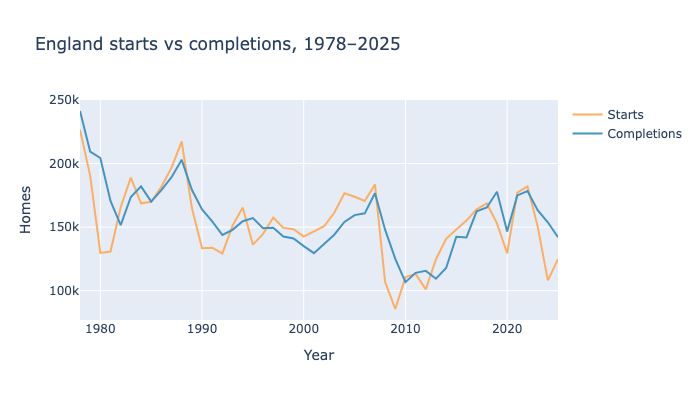

In [9]:
eng_pipe = england[
    england['All Starts'].notna()
][['year', 'All Starts', 'All Completions']].copy()
eng_pipe_long = eng_pipe.melt(
    id_vars='year',
    value_vars=['All Starts', 'All Completions'],
    var_name='metric', value_name='homes',
)
eng_pipe_long['metric'] = eng_pipe_long['metric'].str.replace('All ', '', regex=False)

fig = px.line(
    eng_pipe_long,
    x='year', y='homes', color='metric',
    title='England starts vs completions, 1978\u20132025',
    labels={'homes': 'Homes', 'year': 'Year', 'metric': ''},
    color_discrete_map={'Starts': '#fdae61', 'Completions': '#4393c3'},
)
fig.update_layout(height=400, hovermode='x unified')
fig.write_image(str(FIGURES / '07_england_pipeline.png'))
display(IPImage(str(FIGURES / '07_england_pipeline.png')))

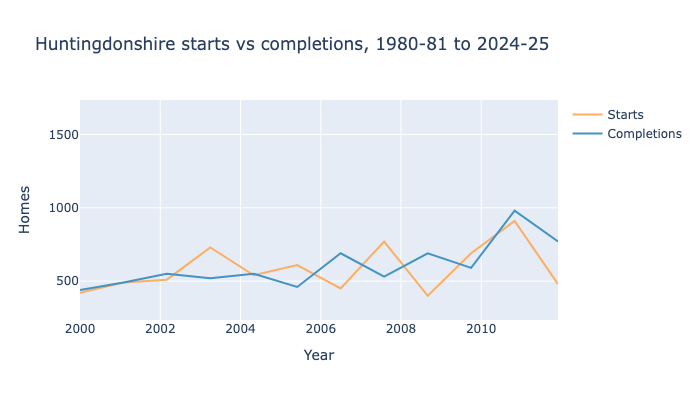

Huntingdonshire starts vs completions, recent years:
   year  all_starts  all_completions
2017-18         930              630
2018-19         770              850
2019-20        1030             1070
2020-21         680              830
2021-22        1010              890
2022-23        1470             1020
2023-24         910             1440
2024-25         700              920


In [10]:
hdc_sc = starts_la[starts_la['ons_code'] == HDC_CODE].sort_values('year').copy()
hdc_sc_long = hdc_sc[['year', 'all_starts', 'all_completions']].melt(
    id_vars='year',
    value_vars=['all_starts', 'all_completions'],
    var_name='metric', value_name='homes',
)
hdc_sc_long['metric'] = hdc_sc_long['metric'].map(
    {'all_starts': 'Starts', 'all_completions': 'Completions'}
)

fig = px.line(
    hdc_sc_long,
    x='year', y='homes', color='metric',
    title='Huntingdonshire starts vs completions, 1980-81 to 2024-25',
    labels={'homes': 'Homes', 'year': 'Year', 'metric': ''},
    color_discrete_map={'Starts': '#fdae61', 'Completions': '#4393c3'},
)
fig.update_layout(height=400, hovermode='x unified')
fig.write_image(str(FIGURES / '08_hdc_pipeline.png'))
display(IPImage(str(FIGURES / '08_hdc_pipeline.png')))

print('Huntingdonshire starts vs completions, recent years:')
print(hdc_sc[['year','all_starts','all_completions']].tail(8).to_string(index=False))

Nationally, starts fell sharply after 2022 as rising interest rates increased the cost of development finance. By 2023-24 completions were running ahead of starts: the industry was finishing sites begun in 2021-22 while starting fewer new ones. That inversion is a reliable signal that future completions will fall.

The Huntingdonshire picture is sharper. In 2022-23 starts hit 1,470 against completions of 1,020, building a strong pipeline. By 2023-24 that had inverted: completions were 1,440 against starts of just 910, as developers worked through earlier commitments. In 2024-25 both fell, starts to 700 and completions to 920. If starts remain in the 700-900 range, a completions figure below 1,000 in 2025-26 is likely.

## Summary

The key findings from the exploratory analysis:

- England delivered 208,600 net additions in 2024-25, 30% below the 300,000 target.
- The East of England peaked at 30,771 in 2022-23 and has fallen 15% since.
- Huntingdonshire at 858 net additions in 2024-25 is still in the upper tier of shire district delivery, but the provisional figure represents a 31% fall from the 2022-23 peak.
- Affordable housing delivery fell from 590 to 328 and the affordable rate dropped from 47% to 38% in 2024-25.
- The starts pipeline (700 in 2024-25) points to further completions pressure ahead.
- The national tenure shift from social rent to affordable rent is visible in Huntingdonshire's own data.

Next: Streamlit dashboard.